In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from rdflib import Graph

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

# Load the knowledge graph emitted by knowledge_graph.ipynb.
g = Graph()
g.parse("../data/processed/data.ttl", format="turtle")
print(f"Knowledge graph loaded: {len(g):,} triples")

Knowledge graph loaded: 71,739 triples


In [6]:
def run_query(sparql: str) -> pd.DataFrame:
    """Run a SPARQL SELECT against the graph and return a typed DataFrame.

    Binding values are converted with rdflib's ``.toPython()``; unbound OPTIONAL
    cells become ``NaN``. Columns that are fully numeric are then coerced so we
    can do arithmetic and plotting. This single helper backs all five queries.
    """
    res = g.query(sparql)
    cols = [str(v) for v in res.vars]
    rows = [
        [(b.get(v).toPython() if b.get(v) is not None else None) for v in res.vars]
        for b in res.bindings
    ]
    df = pd.DataFrame(rows, columns=cols)
    for c in df.columns:
        coerced = pd.to_numeric(df[c], errors="coerce")
        # adopt the numeric version only if no real value was lost (i.e. truly numeric)
        if coerced.notna().sum() >= df[c].notna().sum():
            df[c] = coerced
    return df

In [18]:
q1 = """
PREFIX ein: <http://eindhoven.nl/livability/>
SELECT ?name (?p2 - ?p1 AS ?growth)
       ?supermarket ?groceries ?gp ?pharmacy ?primarySchool ?daycare ?trainStation
WHERE {
  ?nb ein:hasName ?name ; ein:hasObservation ?o1 , ?o2 .
  ?o1 ein:inYear 2015 ; ein:population ?p1 .
  ?o2 ein:inYear 2025 ; ein:population ?p2 ;
      ein:distSupermarket    ?supermarket ;
      ein:distDailyGroceries ?groceries ;
      ein:distGpPractice     ?gp ;
      ein:distPharmacy       ?pharmacy ;
      ein:distPrimarySchool  ?primarySchool ;
      ein:distDaycare        ?daycare ;
      ein:distTrainStation   ?trainStation .
  FILTER (?p2 > ?p1)
}
ORDER BY DESC(?growth)
"""

Q2 = """
PREFIX ein: <http://eindhoven.nl/livability/>
SELECT ?name (?p2 - ?p1 AS ?popGrowth) (?dw2 - ?dw1 AS ?dwellingGrowth) ?pctOccupied2025
WHERE {
  ?nb ein:hasName ?name ; ein:hasObservation ?o1 , ?o2 .
  ?o1 ein:inYear 2015 ; ein:population ?p1 ; ein:totalDwellings ?dw1 .
  ?o2 ein:inYear 2025 ; ein:population ?p2 ; ein:totalDwellings ?dw2 ;
      ein:pctOccupied ?pctOccupied2025 .
  FILTER (?p2 > ?p1)
}
ORDER BY DESC(?popGrowth)
"""

Q3 = """
PREFIX ein: <http://eindhoven.nl/livability/>
SELECT ?name ?growth
       ((?supermarket + ?groceries + ?gp + ?pharmacy +
         ?primarySchool + ?daycare + ?trainStation) / 7 AS ?avgEssentialKm)
WHERE {
  ?nb ein:hasName ?name ; ein:hasObservation ?o1 , ?o2 .
  ?o1 ein:inYear 2015 ; ein:population ?p1 .
  ?o2 ein:inYear 2025 ; ein:population ?p2 ;
      ein:distSupermarket    ?supermarket ;
      ein:distDailyGroceries ?groceries ;
      ein:distGpPractice     ?gp ;
      ein:distPharmacy       ?pharmacy ;
      ein:distPrimarySchool  ?primarySchool ;
      ein:distDaycare        ?daycare ;
      ein:distTrainStation   ?trainStation .
  BIND(?p2 - ?p1 AS ?growth)
  FILTER (?growth > 500)
}
ORDER BY DESC(?avgEssentialKm)
"""

Q4 = """"
PREFIX ein: <http://eindhoven.nl/livability/>
SELECT ?year
       (AVG(?distGp) AS ?avgDistGp) (AVG(?distHospital) AS ?avgDistHospital)
       (AVG(?distPrimary) AS ?avgDistPrimary) (AVG(?distSecondary) AS ?avgDistSecondary)
       (AVG(?distTrain) AS ?avgDistTrain) (AVG(?distSupermarket) AS ?avgDistSupermarket)
       (AVG(?distPharmacy) AS ?avgDistPharmacy) (AVG(?distDaycare) AS ?avgDistDaycare)
       (SUM(?population) AS ?totalPopulation)
WHERE {
    ?obs a ein:Observation ;
         ein:inYear ?year ;
         ein:population ?population .
    OPTIONAL { ?obs ein:distGpPractice ?distGp . }
    OPTIONAL { ?obs ein:distHospital ?distHospital . }
    OPTIONAL { ?obs ein:distPrimarySchool ?distPrimary . }
    OPTIONAL { ?obs ein:distSecondarySchool ?distSecondary . }
    OPTIONAL { ?obs ein:distTrainStation ?distTrain . }
    OPTIONAL { ?obs ein:distSupermarket ?distSupermarket . }
    OPTIONAL { ?obs ein:distPharmacy ?distPharmacy . }
    OPTIONAL { ?obs ein:distDaycare ?distDaycare . }
}
GROUP BY ?year ORDER BY ?year
"""

Q5 = """
PREFIX ein: <http://eindhoven.nl/livability/>
SELECT ?neighborhood ?distGp ?distHospital ?distPrimary ?distSecondary ?distTrain ?population
WHERE {
  ?nb ein:hasName ?neighborhood ;
      ein:hasObservation ?obs .
  ?obs ein:inYear 2024 ;
       ein:distGpPractice      ?distGp ;
       ein:distHospital        ?distHospital ;
       ein:distPrimarySchool   ?distPrimary ;
       ein:distSecondarySchool ?distSecondary ;
       ein:distTrainStation    ?distTrain ;
       ein:population          ?population .
}
ORDER BY DESC(?distGp) LIMIT 10
"""

q1_df = run_query(q1)
print(f"{len(q1_df)} neighbourhoods grew in population between 2015 and 2025")
q1_df.head(15)
q2_df = run_query(Q2)
print(f"{len(q2_df)} neighbourhoods grew in population between 2015 and 2025")
q2_df.head(15)
q3_df = run_query(Q3)
print(f"{len(q3_df)} neighbourhoods had poor average access to essential facilities in 2025")
q3_df.head(15)
q5_df = run_query(Q5)
print(f"{len(q5_df)} neighbourhoods with GP distance data for 2024")
q5_df.head(15)


81 neighbourhoods grew in population between 2015 and 2025
77 neighbourhoods grew in population between 2015 and 2025
20 neighbourhoods had poor average access to essential facilities in 2025
10 neighbourhoods with GP distance data for 2024


,neighborhood,distGp,distHospital,distPrimary,distSecondary,distTrain,population
0,BeA2,4.0,6.8,3.2,3.4,5.5,28.0
1,Mispelhoef,4.0,6.4,2.9,2.9,5.1,19.0
2,Herdgang,3.0,4.4,1.1,1.2,3.0,13.0
3,Wielewaal,2.9,4.9,1.1,1.1,3.5,115.0
4,Bosrijk,2.6,5.8,0.9,4.6,5.7,606.0
5,Park Forum,2.6,6.2,2.3,6.1,7.2,25.0
6,Grasrijk,2.2,4.7,1.2,3.6,4.7,5950.0
7,Meerbos,2.1,5.6,1.6,2.5,3.8,60.0
8,Bokt,1.9,4.9,1.6,1.9,6.5,127.0
9,Esp,1.9,4.8,1.8,1.8,6.4,18.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch
 
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.0)
plt.rcParams["figure.dpi"] = 120
 
# ── shared column/label maps ──────────────────────────────────────────────────
facility_cols = ["supermarket", "groceries", "gp", "pharmacy",
                 "primarySchool", "daycare", "trainStation"]
FACILITY_LABELS = {
    "supermarket":   "Supermarket",
    "groceries":     "Daily groceries",
    "gp":            "GP practice",
    "pharmacy":      "Pharmacy",
    "primarySchool": "Primary school",
    "daycare":       "Daycare",
    "trainStation":  "Train station",
}
Q4_DIST_COLS = [
    "avgDistGp", "avgDistHospital", "avgDistPrimary", "avgDistSecondary",
    "avgDistTrain", "avgDistSupermarket", "avgDistPharmacy", "avgDistDaycare",
]
Q4_LABELS = {
    "avgDistGp":          "GP practice",
    "avgDistHospital":    "Hospital",
    "avgDistPrimary":     "Primary school",
    "avgDistSecondary":   "Secondary school",
    "avgDistTrain":       "Train station",
    "avgDistSupermarket": "Supermarket",
    "avgDistPharmacy":    "Pharmacy",
    "avgDistDaycare":     "Daycare",
}
Q5_DIST_COLS = ["distGp", "distHospital", "distPrimary", "distSecondary", "distTrain"]
Q5_LABELS = {
    "distGp":         "GP",
    "distHospital":   "Hospital",
    "distPrimary":    "Primary school",
    "distSecondary":  "Secondary school",
    "distTrain":      "Train station",
}


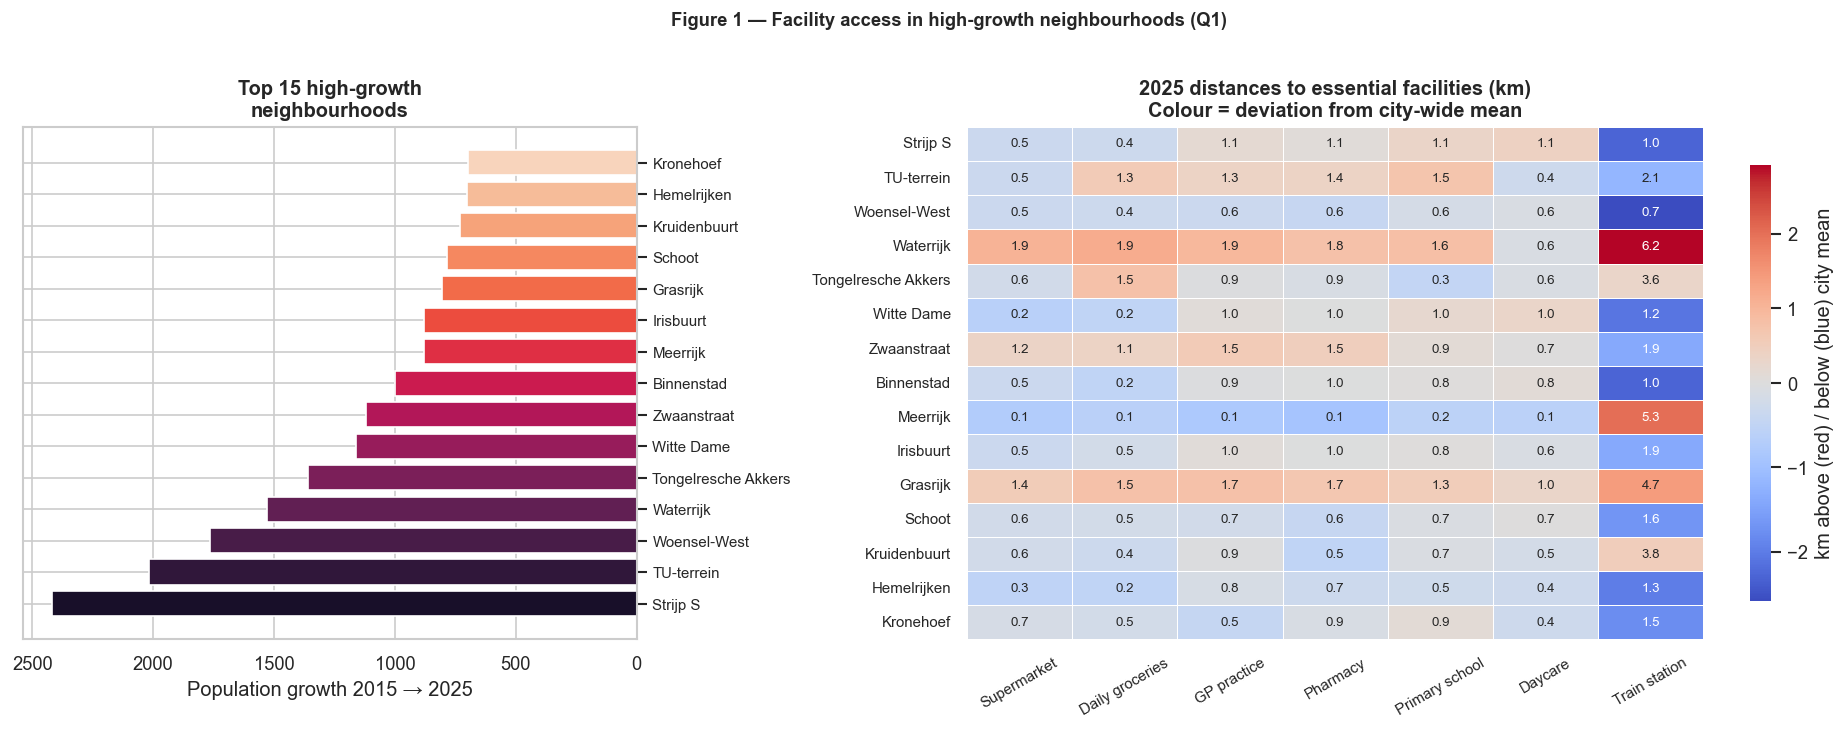

Saved → fig1_q1_heatmap.png


In [ ]:
# =============================================================================
# Figure 1 — PRIMARY HEATMAP
# Q1: facility access in the top-15 high-growth neighbourhoods (deviation map)
# =============================================================================
top15 = q1_df.head(15).copy()
city_mean = q1_df[facility_cols].mean()
 
row_order = top15.sort_values("growth")["name"][::-1]   # largest growth at top
abs_km    = top15.set_index("name")[facility_cols].loc[row_order]
dev       = abs_km.subtract(city_mean, axis=1)           # deviation from city mean
 
pretty_cols = [FACILITY_LABELS[c] for c in facility_cols]
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                         gridspec_kw={"width_ratios": [1, 1.5]})
 
# Left: population growth bar chart
growth_order = top15.set_index("name").loc[row_order, "growth"]
palette = sns.color_palette("rocket", len(growth_order))
axes[0].barh(range(len(growth_order)), growth_order.values, color=palette)
axes[0].set_yticks(range(len(growth_order)))
axes[0].set_yticklabels(growth_order.index, fontsize=9)
axes[0].set_xlabel("Population growth 2015 → 2025")
axes[0].set_title("Top 15 high-growth\nneighbourhoods", fontweight="bold")
axes[0].invert_xaxis()
axes[0].yaxis.set_label_position("right")
axes[0].yaxis.tick_right()
 
# Right: deviation heatmap
dev_display = dev.copy()
dev_display.columns = pretty_cols
norm = TwoSlopeNorm(vmin=dev_display.values.min(), vcenter=0,
                    vmax=dev_display.values.max())
sns.heatmap(
    dev_display,
    cmap="coolwarm", norm=norm,
    annot=abs_km.values, fmt=".1f",
    annot_kws={"size": 8},
    cbar_kws={"label": "km above (red) / below (blue) city mean",
              "shrink": 0.85},
    ax=axes[1], linewidths=0.4, linecolor="white",
)
axes[1].set_title("2025 distances to essential facilities (km)\n"
                  "Colour = deviation from city-wide mean", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=30, labelsize=9)
axes[1].tick_params(axis="y", labelsize=9)
 
plt.suptitle("Figure 1 — Facility access in high-growth neighbourhoods (Q1)",
             y=1.01, fontsize=11, fontweight="bold")
plt.tight_layout()
#plt.savefig("fig1_q1_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()
#print("Saved → fig1_q1_heatmap.png")

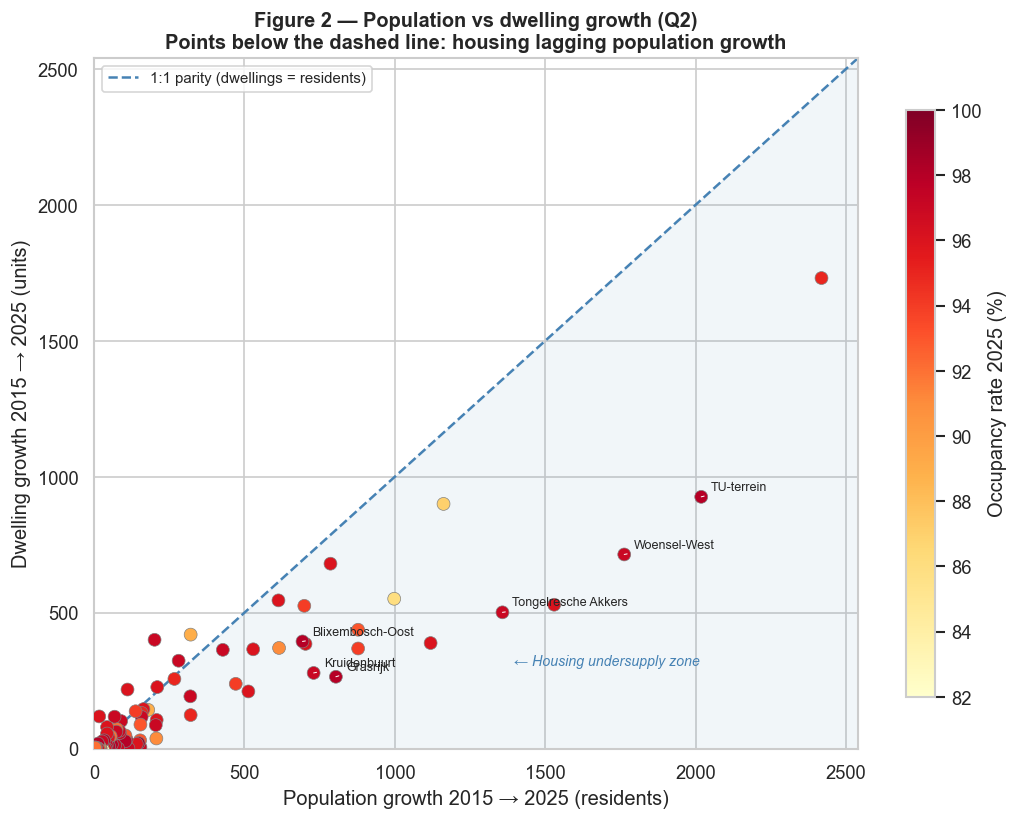

Saved → fig2_q2_housing_scatter.png


In [ ]:
# =============================================================================
# Figure 2 — HOUSING STRESS SCATTER
# Q2: population growth vs dwelling growth, coloured by occupancy rate
# =============================================================================
fig, ax = plt.subplots(figsize=(9, 7))
 
sc = ax.scatter(
    q2_df["popGrowth"], q2_df["dwellingGrowth"],
    c=q2_df["pctOccupied2025"] * 100,
    cmap="YlOrRd", vmin=82, vmax=100,
    s=60, edgecolors="grey", linewidths=0.4, zorder=3,
)
cb = fig.colorbar(sc, ax=ax, label="Occupancy rate 2025 (%)", shrink=0.85)
 
# 1:1 parity line
lim = max(q2_df["popGrowth"].max(), q2_df["dwellingGrowth"].max()) * 1.05
ax.plot([0, lim], [0, lim], color="steelblue", lw=1.5, ls="--",
        label="1:1 parity (dwellings = residents)")
ax.fill_between([0, lim], [0, 0], [0, lim], alpha=0.07, color="steelblue")
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
 
# Annotate high-stress cases (high growth, near-full occupancy, low ratio)
high_stress = q2_df[
    (q2_df["pctOccupied2025"] >= 0.97) &
    (q2_df["popGrowth"] >= 500)
].copy()
for _, row in high_stress.iterrows():
    ax.annotate(row["name"], (row["popGrowth"], row["dwellingGrowth"]),
                fontsize=7.5, xytext=(6, 4), textcoords="offset points",
                arrowprops=dict(arrowstyle="-", lw=0.6))
 
ax.set_xlabel("Population growth 2015 → 2025 (residents)")
ax.set_ylabel("Dwelling growth 2015 → 2025 (units)")
ax.set_title("Figure 2 — Population vs dwelling growth (Q2)\n"
             "Points below the dashed line: housing lagging population growth",
             fontweight="bold")
ax.legend(fontsize=9)
ax.text(lim * 0.55, lim * 0.12, "← Housing undersupply zone",
        color="steelblue", fontsize=8.5, style="italic")
plt.tight_layout()
#plt.savefig("fig2_q2_housing_scatter.png", bbox_inches="tight", dpi=150)
plt.show()
#print("Saved → fig2_q2_housing_scatter.png")
 
 


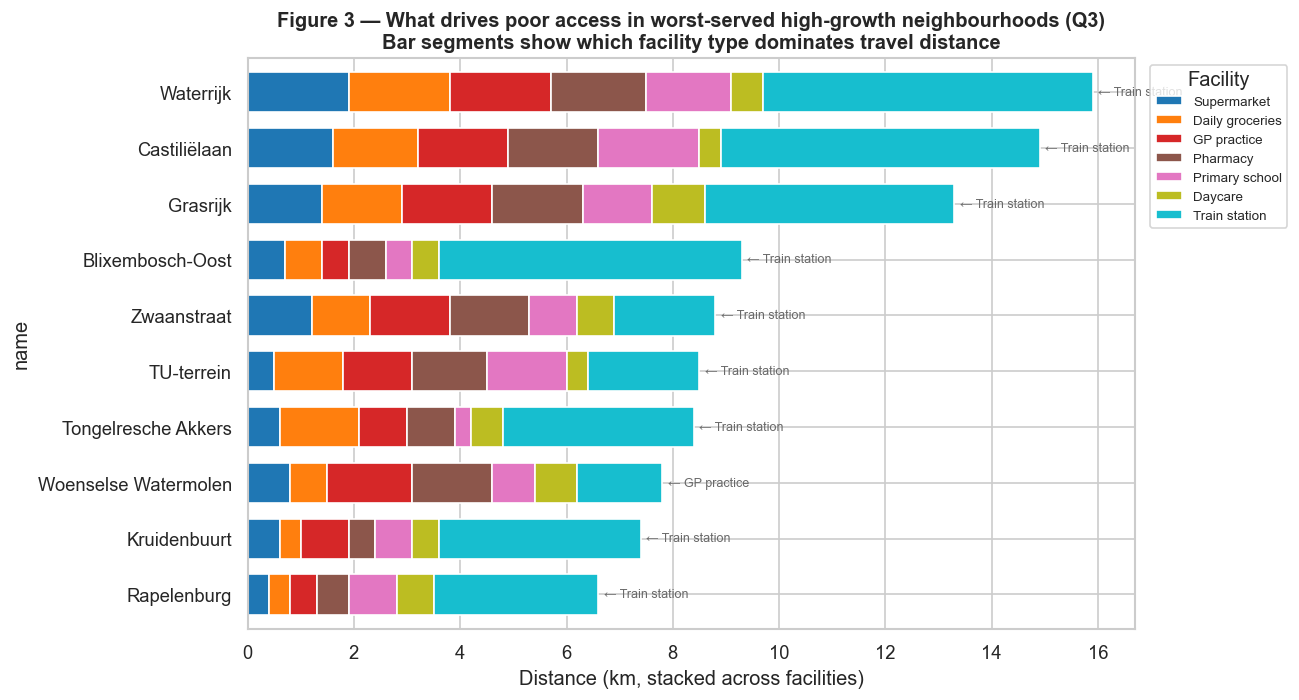

Saved → fig3_q3_stacked_driver.png


In [ ]:
# =============================================================================
# Figure 3 — WORST-FACILITY DRIVER (stacked bar, Q3)
# Which facility drives poor access in the highest-growth neighbourhoods?
# =============================================================================
top_n  = min(10, len(q3_df))
worst  = q3_df.head(top_n).copy()
 
# Pull absolute distances from q1_df for the same set of neighbourhoods
q1_idx = q1_df.set_index("name")
shared  = [n for n in worst["name"] if n in q1_idx.index]
worst   = worst[worst["name"].isin(shared)].copy()
comp    = q1_idx.loc[worst["name"], facility_cols].reset_index()
comp    = comp.set_index("name")
comp.columns = [FACILITY_LABELS[c] for c in comp.columns]
 
fig, ax = plt.subplots(figsize=(11, 6))
comp.plot(kind="barh", stacked=True, ax=ax,
          colormap="tab10", width=0.72)
ax.invert_yaxis()
ax.set_xlabel("Distance (km, stacked across facilities)")
ax.set_title("Figure 3 — What drives poor access in worst-served high-growth neighbourhoods (Q3)\n"
             "Bar segments show which facility type dominates travel distance",
             fontweight="bold")
ax.legend(title="Facility", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
 
# Annotate worst facility per row
for idx, (nb, row) in enumerate(comp.iterrows()):
    worst_f = row.idxmax()
    ax.text(row.sum() + 0.1, idx, f"← {worst_f}", va="center", fontsize=7.5,
            color="dimgray")
 
plt.tight_layout()
#plt.savefig("fig3_q3_stacked_driver.png", bbox_inches="tight", dpi=150)
plt.show()
#print("Saved → fig3_q3_stacked_driver.png")
 

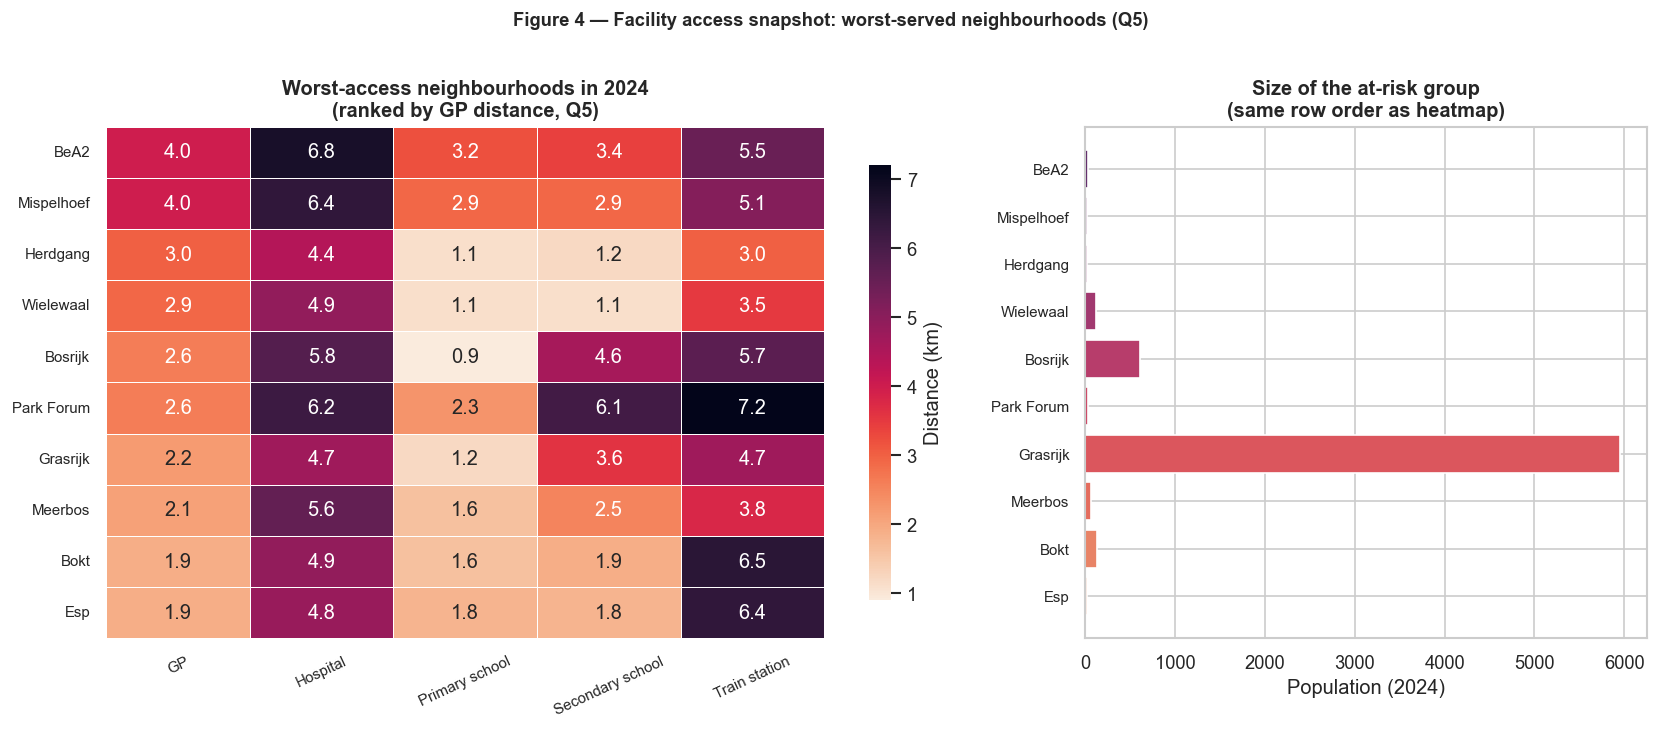

In [25]:
# =============================================================================
# Figure 4 — WORST-ACCESS SNAPSHOT HEATMAP (Q4) — the requested primary output
# Left: facility distance heatmap; Right: population at stake
# =============================================================================
hm_data = q5_df.set_index("neighborhood")[Q5_DIST_COLS].copy()
hm_data.columns = [Q5_LABELS[c] for c in hm_data.columns]
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6),
                         gridspec_kw={"width_ratios": [1.6, 1]})
 
# Heatmap
sns.heatmap(
    hm_data,
    annot=True, fmt=".1f",
    cmap="rocket_r",
    linewidths=0.4, linecolor="white",
    cbar_kws={"label": "Distance (km)", "shrink": 0.85},
    ax=axes[0],
)
axes[0].set_title("Worst-access neighbourhoods in 2024\n(ranked by GP distance, Q5)",
                  fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("")
axes[0].tick_params(axis="x", rotation=25, labelsize=9)
axes[0].tick_params(axis="y", labelsize=9)
 
# Population bar (reversed so largest-growth is at the top, matching heatmap)
pop_order = q5_df.iloc[::-1].copy()
bar_colours = sns.color_palette("flare", len(pop_order))
axes[1].barh(pop_order["neighborhood"], pop_order["population"],
             color=bar_colours)
axes[1].set_xlabel("Population (2024)")
axes[1].set_title("Size of the at-risk group\n(same row order as heatmap)",
                  fontweight="bold")
axes[1].tick_params(axis="y", labelsize=9)
 
plt.suptitle("Figure 4 — Facility access snapshot: worst-served neighbourhoods (Q5)",
             y=1.01, fontsize=11, fontweight="bold")
plt.tight_layout()
#plt.savefig("fig4_q4_access_heatmap.png", bbox_inches="tight", dpi=150)
plt.show()
#print("Saved → fig4_q4_access_heatmap.png")
 